# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [38]:
# Replace this list with your selected tickers
tickers = ['mcd', 'wing', 'dpz', 'shak']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [39]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [40]:
# Download adjusted close prices
df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']

/tmp/ipykernel_5405/3450391006.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']
[*********************100%***********************]  4 of 4 completed


In [41]:
df.head()

Ticker,DPZ,MCD,SHAK,WING
Date,,,,
2020-01-02,273.293076,173.802594,61.619999,78.703783
2020-01-03,273.441295,173.586192,60.896999,81.182803
2020-01-06,272.626337,175.507737,60.830002,81.354684
2020-01-07,271.579834,175.429803,61.500000,83.408472
2020-01-08,270.607446,178.900684,62.520000,82.322769


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [42]:
print("Missing values before filling:")
print(df.isnull().sum())

# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

print("\nMissing values after forward fill:")
print(df.isnull().sum())

Missing values before filling:
Ticker
DPZ     0
MCD     0
SHAK    0
WING    0
dtype: int64

Missing values after forward fill:
Ticker
DPZ     0
MCD     0
SHAK    0
WING    0
dtype: int64


/tmp/ipykernel_5405/3308999741.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [43]:
returns = df.pct_change()
returns.dropna(inplace=True)
returns.head()

Ticker,DPZ,MCD,SHAK,WING
Date,,,,
2020-01-03,0.000542,-0.001245,-0.011733,0.031498
2020-01-06,-0.002980,0.011070,-0.001100,0.002117
2020-01-07,-0.003839,-0.000444,0.011014,0.025245
2020-01-08,-0.003580,0.019785,0.016585,-0.013017
2020-01-09,0.004996,0.012966,-0.009917,0.013859


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




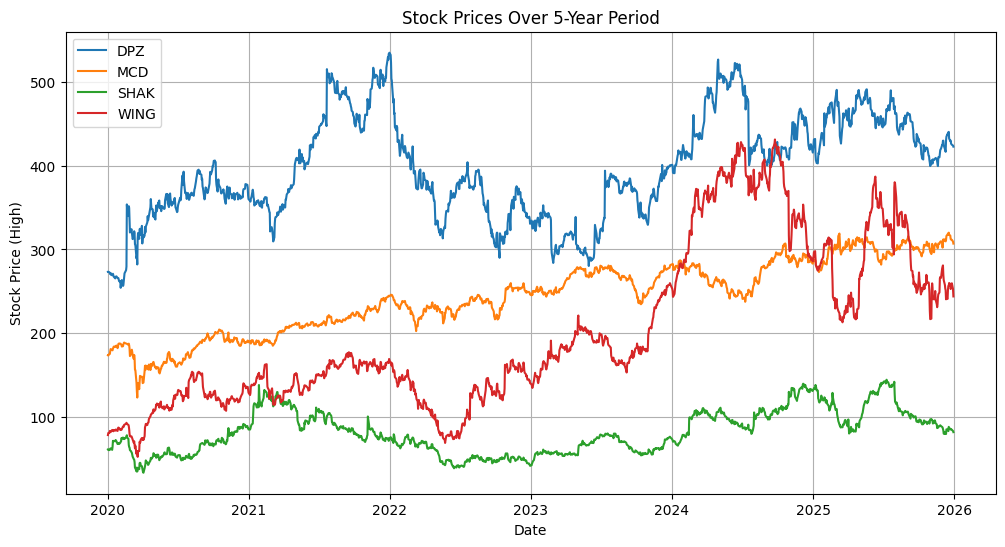


Standard Deviation of Daily Returns (Volatility):
Ticker
DPZ     0.018930
MCD     0.012087
SHAK    0.032664
WING    0.029601
dtype: float64

Correlation Matrix of Daily Returns:
Ticker       DPZ       MCD      SHAK      WING
Ticker                                        
DPZ     1.000000  0.257402  0.173142  0.256090
MCD     0.257402  1.000000  0.281550  0.244843
SHAK    0.173142  0.281550  1.000000  0.323919
WING    0.256090  0.244843  0.323919  1.000000


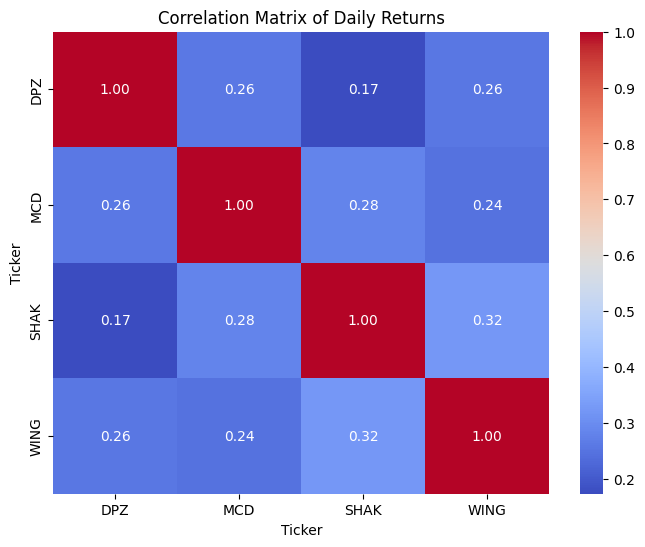

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a line chart showing stock prices over the 5-year period.
plt.figure(figsize=(12, 6))
for ticker in df.columns:
    plt.plot(df.index, df[ticker], label=ticker)
plt.title('Stock Prices Over 5-Year Period')
plt.xlabel('Date')
plt.ylabel('Stock Price (High)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Calculate the standard deviation of daily returns for each stock (volatility).
volatility = returns.std()
print('\nStandard Deviation of Daily Returns (Volatility):')
print(volatility)

# 3. Create a correlation matrix of the daily returns between companies.
correlation_matrix = returns.corr()
print('\nCorrelation Matrix of Daily Returns:')
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Daily Returns')
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Investment Recommendation Memo

**To:** Stakeholder

**Subject:** Evaluation of Investment Opportunity in the Fast Food Industry (2020-2025)

This memo presents an evaluation of the Fast Food industry specifically focusing on the performance of four key public companies: McDonald's (MCD), Wingstop (WING), Domino's Pizza (DPZ), and Shake Shack (SHAK), over the past five years January 2020 to December 2025.

Over the past five years, the stock prices of these fast food companies generally exhibited an upward trend indicating overall growth in the sector. However, there were some fluctuations particularly during early 2020, likely influenced by the COVID-19 pandemic. McDonald's (MCD) showed the lowest volatility with a daily return standard deviation of approximately 0.012. Shake Shack (SHAK) and Wingstop (WING) showed higher volatility, with standard deviations around 0.032 and 0.029, respectively, indicating greater price swings. The correlation matrix reveals positive correlations among all companies ranging from 0.17 to 0.32. This suggests that while their movements are not perfectly synchronized, they tend to move in the same general direction.

Based on this evidence, investing in the fast food industry in a long term basis would be of benefit but in the short term expect high volatility.  McDonald's seems to be the most stable option due to its lower volatility and consistent growth. While Shake Shack and Wingstop offer potential for higher returns, they also come with increased risk due to their higher volatility. If what stakeholders seek is a stable investment the best recommendation would be Mcdonalds. On the other hand if stakeholders are looking for riskier yet higher returns Wingstop or Shak would be suitable choices.

Some suggestions to improving this model and recommendation would be incorporating additional data sets that include information such as macroeconomic indicators (inflation), individual financial reportings of these companies, etc. A sentiment analysis on the reviews of each company could be of benefit as these could be indicators of improvements or lack of improvements that would be insightful for recommendations. With this data we can also include a forecasting model which would be trained and tested to ensure accuracy and provide additional information.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [45]:
!jupyter nbconvert --to html "VegaSamantha_api.ipynb"

[NbConvertApp] Converting notebook VegaSamantha_api.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 529876 bytes to VegaSamantha_api.html
